In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud
import re
import matplotlib.pyplot as plt
import seaborn as sns
import string
import os

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\QUOC
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\QUOC
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\QUOC
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 1. Đọc và Kiểm tra dữ liệu

In [ ]:
# 1. Đọc dữ liệu từ file csv
df_fake = pd.read_csv('../data/raw/Fake.csv')
df_true = pd.read_csv('../data/raw/True.csv')

# 2. Gán nhãn (1: Fake, 0: True)
df_fake['label'] = 1
df_true['label'] = 0

# 3. Gộp 2 DataFrame và xáo trộn
df = pd.concat([df_fake, df_true], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Đã đọc và gộp dữ liệu thành công.")
# Hợp nhất tiêu đề và nội dung để có dữ liệu văn bản đầy đủ (tùy chọn)
# df['text'] = df['title'] + " " + df['text']

# df['text'] = df['text'].str.replace(r'^.*?\(reuters\) - ', '', regex=True, flags=re.IGNORECASE)
# df = df.dropna(subset=['text'])
# df['text'] = df['text'].astype(str)

print(df.head())

Đã đọc và gộp dữ liệu thành công.
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      1  
1       April 5, 2017       0  
2  September 27, 2017       0  
3         May 22, 2017      1  
4       June 24, 2016       0  


In [ ]:
# Thống kê quy mô và cấu trúc
num_samples, num_features = df.shape
label_counts = df['label'].value_counts()

print(f"=== THỐNG KÊ BAN ĐẦU ===")
print(f"Tổng số mẫu: {num_samples}")
print(f"Số đặc trưng: {num_features}")
print(f"Danh sách cột: {list(df.columns)}")
print("-" * 30)
print(f"Số lượng tin giả (Label 1): {label_counts[1]}")
print(f"Số lượng tin thật (Label 0): {label_counts[0]}")
print(f"Tỷ lệ tin giả: {(label_counts[1]/num_samples)*100:.2f}%")

=== THỐNG KÊ BAN ĐẦU ===
Tổng số mẫu: 44898
Số đặc trưng: 5
Danh sách cột: ['title', 'text', 'subject', 'date', 'label']
------------------------------
Số lượng tin giả (Label 1): 23481
Số lượng tin thật (Label 0): 21417
Tỷ lệ tin giả: 52.30%


In [ ]:
print("=== KIỂM TRA ĐỘ SẠCH ===")
# 1. Kiểm tra giá trị thiếu (NaN)
print("Giá trị thiếu trên từng cột:")
print(df.isnull().sum())

# 2. Kiểm tra dòng trùng lặp hoàn toàn
print(f"\nSố dòng trùng lặp hoàn toàn: {df.duplicated().sum()}")

# 3. Kiểm tra trùng lặp nội dung văn bản (Quan trọng nhất)
print(f"Số dòng trùng lặp nội dung 'text': {df.duplicated(subset=['text']).sum()}")

=== KIỂM TRA ĐỘ SẠCH ===
Giá trị thiếu trên từng cột:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Số dòng trùng lặp hoàn toàn: 209
Số dòng trùng lặp nội dung 'text': 6252


## 2. Làm sạch dữ liệu cơ bản

In [ ]:
# 1. Loại bỏ các cột không cần thiết (Tránh Data Leakage)
cols_to_drop = ['subject', 'date']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

# 2. Xử lý trùng lặp dựa trên nội dung bài báo
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

# 3. Loại bỏ giá trị thiếu (NaN) và các dòng text rỗng/chỉ chứa khoảng trắng
df = df.dropna().reset_index(drop=True)
df = df[df['text'].str.strip() != ""].reset_index(drop=True)

# 4. Xóa dấu hiệu nguồn tin (ví dụ: "WASHINGTON (Reuters) -")
def deep_clean_text(text):
    # 1. Xử lý Header (Nguồn tin & Địa danh) - Phải làm đầu tiên
    # Xóa pattern "CITY (Reuters) -"
    text = re.sub(r'^.*?\(reuters\)\s*[-–—]\s*', '', str(text), flags=re.IGNORECASE)
    # Xóa pattern "CITY -" ở đầu câu
    text = re.sub(r'^.*?\s?[-–—]\s?', '', text, count=1)
    
    # 2. Chuẩn hóa cơ bản
    text = text.lower() # Chuyển về chữ thường
    
    # 3. Xử lý ký tự đặc biệt "rác" trên môi trường web
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Xóa URL
    text = re.sub(r'<.*?>', '', text) # Xóa thẻ HTML
    
    # 4. Xử lý dấu câu và ký tự đặc biệt còn lại
    # Sử dụng string.punctuation để quét sạch các ký tự rác
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 5. Xử lý khoảng trắng và xuống dòng
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['text'] = df['text'].apply(deep_clean_text)
df['title'] = df['title'].apply(deep_clean_text)
# 5. Tạo 2 phiên bản dữ liệu để thử nghiệm đa kỹ thuật
# Phiên bản 1: Chỉ lấy nội dung (Text Only)
df['text_only'] = df['text']

# Phiên bản 2: Kết hợp Tiêu đề + Nội dung (Title + Text)
df['title_text'] = df['title'] + " " + df['text']

print("Làm sạch hoàn tất. Đã tạo 2 phiên bản: 'text_only' và 'title_text'.")

Làm sạch hoàn tất. Đã tạo 2 phiên bản: 'text_only' và 'title_text'.


## 3. Chuẩn hóa ngôn ngữ

In [ ]:
# 1. Khởi tạo Lemmatizer và bộ Stop words chuyên biệt
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Bổ sung các từ chuyên biệt cho tin tức chính trị thường xuất hiện nhiều nhưng ít giá trị phân loại
political_stopwords = {'said', 'also', 'would', 'could', 'told', 'reuters', 'washington', 'statement', 'press'}
stop_words.update(political_stopwords)

def final_preprocess(text):
    # a. Chuyển về chữ thường
    text = str(text).lower()
    
    # b. Loại bỏ dấu câu
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # c. Tách từ, loại bỏ stop words và thực hiện Lemmatization
    words = text.split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(clean_words)

# 2. Áp dụng chuẩn hóa ngôn ngữ cho cột dữ liệu
print("Đang chuẩn hóa ngôn ngữ (Lemmatization)...")
df['text_only_clean'] = df['text_only'].apply(final_preprocess)
df['title_text_clean'] = df['title_text'].apply(final_preprocess)
print("Chuẩn hóa thành công")

Đang chuẩn hóa ngôn ngữ (Lemmatization)...
Chuẩn hóa thành công


## 4. Sản phẩm

In [ ]:
# Lưu vào thư mục processed sau khi đã chuẩn hóa xong
output_path = '../data/processed/processed_data.csv'
os.makedirs('../data/processed', exist_ok=True)

# Lưu đầy đủ các cột để sau này so sánh (text thô và text đã chuẩn hóa)
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Đã chuẩn hóa xong và lưu tại: {output_path}")
print(f"Cột dữ liệu mới sẵn sàng cho huấn luyện: 'text_only_clean' và 'title_text_clean'")

Đã chuẩn hóa xong và lưu tại: ../data/processed/processed_data.csv
Cột dữ liệu mới sẵn sàng cho huấn luyện: 'text_only_clean' và 'title_text_clean'


## 5. Phân tích dữ liệu (EDA)


1. THỐNG KÊ CƠ BẢN
Tổng số mẫu: 38644
Số đặc trưng: 7
Danh sách cột: ['title', 'text', 'label', 'text_only', 'title_text', 'text_only_clean', 'title_text_clean']

2. PHÂN BỐ NHÃN
Tin thật (Label 0): 21191 mẫu (54.84%)
Tin giả (Label 1): 17453 mẫu (45.16%)

3. PHÂN TÍCH MẤT CÂN BẰNG DỮ LIỆU
Tỷ lệ mất cân bằng: 1.21:1
Dữ liệu cân bằng tốt (sai lệch < 10%)

4. BIỂU ĐỒ PHÂN TÍCH


C:\Users\QUOC THINH\AppData\Local\Temp\ipykernel_21580\1151679551.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2', order=[0, 1])
C:\Users\QUOC THINH\AppData\Local\Temp\ipykernel_21580\1151679551.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='text_length', data=df, palette='Set2')


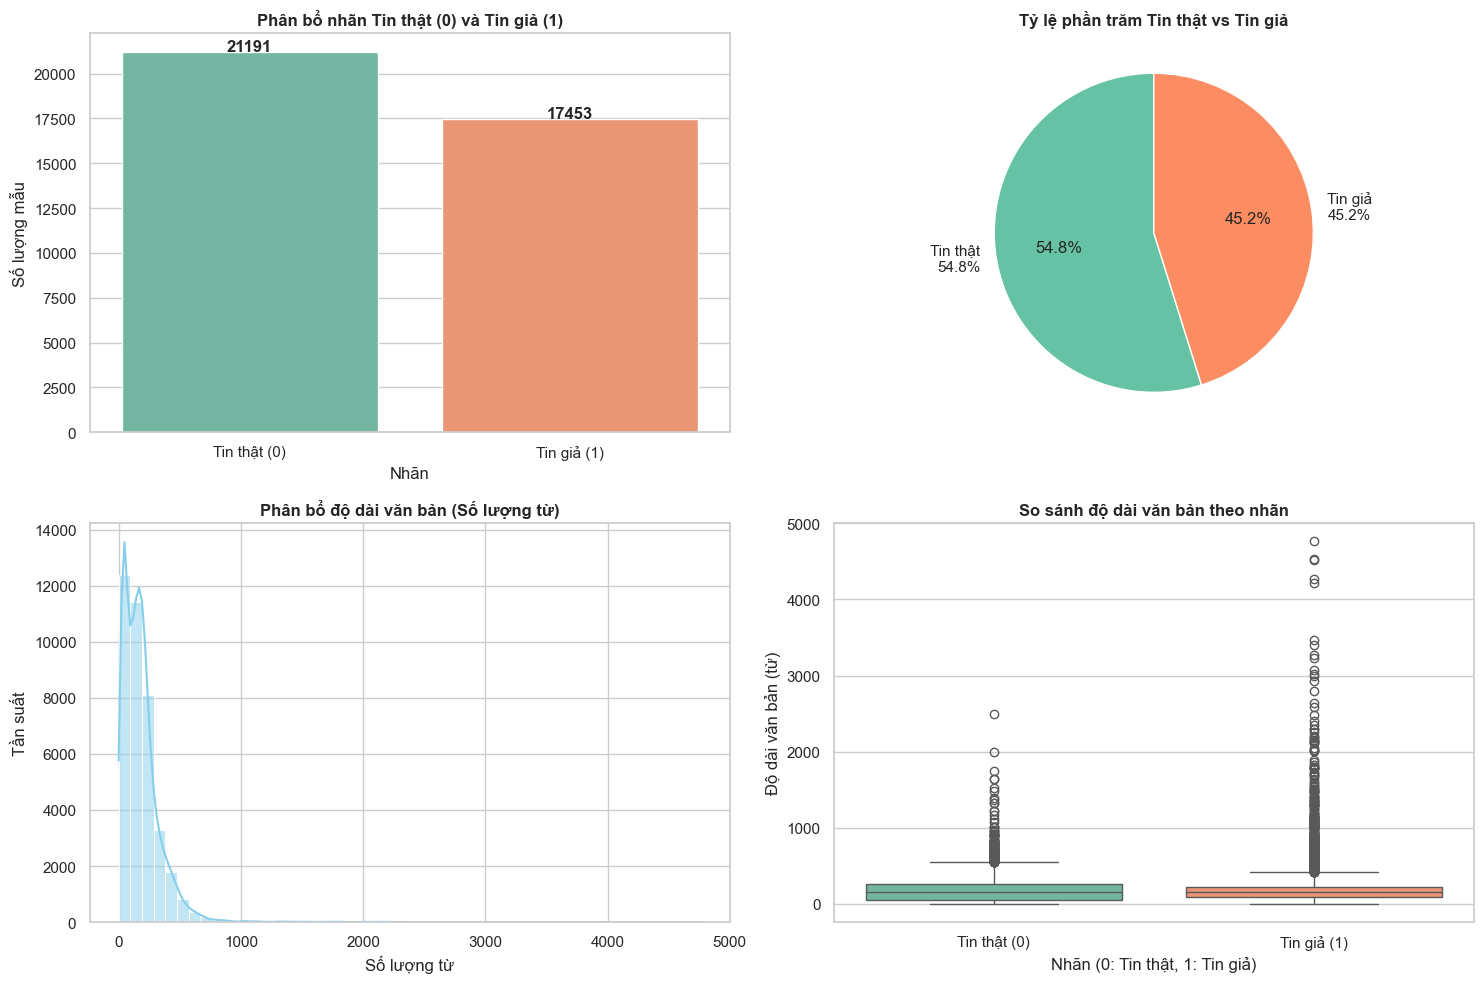


5. THỐNG KÊ CHI TIẾT VỀ ĐỘ DÀI VĂN BẢN

Tin thật (Label 0):
  - Độ dài trung bình: 184 từ
  - Độ dài min: 0 từ
  - Độ dài max: 2500 từ

Tin giả (Label 1):
  - Độ dài trung bình: 182 từ
  - Độ dài min: 0 từ
  - Độ dài max: 4763 từ


In [ ]:
# Thiết lập style cho biểu đồ
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# ===== 1. THỐNG KÊ CƠ BẢN =====
print("\n" + "="*75)
print("1. THỐNG KÊ CƠ BẢN")
print("="*75)

num_samples = len(df)
num_features = len(df.columns)
label_counts = df['label'].value_counts()
true_count = label_counts[0]
fake_count = label_counts[1]

print(f"Tổng số mẫu: {num_samples}")
print(f"Số đặc trưng: {num_features}")
print(f"Danh sách cột: {list(df.columns)}")

# ===== 2. PHÂN BỐ NHÃN =====
print("\n" + "="*75)
print("2. PHÂN BỐ NHÃN")
print("="*75)
print(f"Tin thật (Label 0): {true_count} mẫu ({(true_count/num_samples)*100:.2f}%)")
print(f"Tin giả (Label 1): {fake_count} mẫu ({(fake_count/num_samples)*100:.2f}%)")

# ===== 3. PHÂN TÍCH MẤT CÂN BẰNG DỮ LIỆU =====
print("\n" + "="*75)
print("3. PHÂN TÍCH MẤT CÂN BẰNG DỮ LIỆU")
print("="*75)

imbalance_ratio = max(true_count, fake_count) / min(true_count, fake_count)
print(f"Tỷ lệ mất cân bằng: {imbalance_ratio:.2f}:1")

if abs(true_count - fake_count) / num_samples < 0.1:
    print("Dữ liệu cân bằng tốt (sai lệch < 10%)")
elif abs(true_count - fake_count) / num_samples < 0.2:
    print("Dữ liệu còn mất cân bằng đôi chút (sai lệch 10-20%)")
else:
    print("Dữ liệu mất cân bằng đáng kể (sai lệch > 20%)")

# ===== 4. BIỂU ĐỒ PHÂN TÍCH =====
print("\n" + "="*75)
print("4. BIỂU ĐỒ PHÂN TÍCH")
print("="*75)

# Subplot 1: Countplot - Phân bố nhãn
plt.subplot(2, 2, 1)
sns.countplot(x='label', data=df, palette='Set2', order=[0, 1])
plt.title('Phân bổ nhãn Tin thật (0) và Tin giả (1)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng mẫu')
plt.xticks([0, 1], ['Tin thật (0)', 'Tin giả (1)'])

# Thêm giá trị trên cột
for i, v in enumerate([true_count, fake_count]):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

# Subplot 2: Pie chart - Tỷ lệ phần trăm
plt.subplot(2, 2, 2)
sizes = [true_count, fake_count]
labels = [f'Tin thật\n{(true_count/num_samples)*100:.1f}%', 
          f'Tin giả\n{(fake_count/num_samples)*100:.1f}%']
colors = ['#66c2a5', '#fc8d62']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Tỷ lệ phần trăm Tin thật vs Tin giả', fontsize=12, fontweight='bold')

# Subplot 3: Độ dài văn bản
plt.subplot(2, 2, 3)
df['text_length'] = df['text_only_clean'].apply(lambda x: len(x.split()))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Phân bổ độ dài văn bản (Số lượng từ)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')

# Subplot 4: Boxplot - Độ dài theo nhãn
plt.subplot(2, 2, 4)
sns.boxplot(x='label', y='text_length', data=df, palette='Set2')
plt.title('So sánh độ dài văn bản theo nhãn', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn (0: Tin thật, 1: Tin giả)')
plt.ylabel('Độ dài văn bản (từ)')
plt.xticks([0, 1], ['Tin thật (0)', 'Tin giả (1)'])

plt.tight_layout()
plt.show()

# ===== 5. THỐNG KÊ CHI TIẾT =====
print("\n" + "="*75)
print("5. THỐNG KÊ CHI TIẾT VỀ ĐỘ DÀI VĂN BẢN")
print("="*75)

print("\nTin thật (Label 0):")
print(f"  - Độ dài trung bình: {df[df['label']==0]['text_length'].mean():.0f} từ")
print(f"  - Độ dài min: {df[df['label']==0]['text_length'].min():.0f} từ")
print(f"  - Độ dài max: {df[df['label']==0]['text_length'].max():.0f} từ")

print("\nTin giả (Label 1):")
print(f"  - Độ dài trung bình: {df[df['label']==1]['text_length'].mean():.0f} từ")
print(f"  - Độ dài min: {df[df['label']==1]['text_length'].min():.0f} từ")
print(f"  - Độ dài max: {df[df['label']==1]['text_length'].max():.0f} từ")

### 6. Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===== Khởi tạo TfidfVectorizer một lần duy nhất (tránh Data Leakage) =====
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
tfidf_vectorizer.fit(df['text_only_clean'])

def create_features(text_column):
    
    # Sử dụng vectorizer đã fit
    text_tfidf = tfidf_vectorizer.transform(df[text_column]).toarray()

    # Độ dài văn bản (tính số từ)
    body_len = df[text_column].apply(lambda x: len(x.split()))

    # Tỷ lệ dấu câu - Tính từ text gốc (text chưa xóa dấu)
    def count_punct_words(text):
        words = text.split()
        if len(words) == 0:
            return 0
        # Đếm các ký tự không phải chữ cái, số, khoảng trắng
        punct_count = sum(
            1 for char in text
            if not char.isalnum() and char != ' '
        )
        return round(punct_count / len(words), 3) * 100

    # Tính dấu câu từ text gốc (chưa clean)
    if 'clean' in text_column:
        # Nếu là text_only_clean hoặc title_text_clean, lấy từ text gốc
        if 'title' in text_column:
            base_text = df['title'] + " " + df['text']
        else:
            base_text = df['text']
    else:
        base_text = df[text_column]
    
    punct_per_word = base_text.apply(count_punct_words)

    # Tỷ lệ chữ in hoa (tính từ text gốc)
    def count_cap_words(text):
        words = text.split()
        if len(words) == 0:
            return 0
        cap_count = sum(
            1 for char in text
            if char.isupper()
        )
        return round(cap_count / len(words), 3) * 100

    cap_per_word = base_text.apply(count_cap_words)

    # ===== Combine Features =====

    features_df = pd.DataFrame(text_tfidf, columns=tfidf_vectorizer.get_feature_names_out())

    features_df['body_len'] = body_len
    features_df['punct_per_word'] = punct_per_word
    features_df['cap_per_word'] = cap_per_word

    # ===== Scaling =====

    scaler = MinMaxScaler()

    features_scaled = scaler.fit_transform(features_df)

    final_df = pd.DataFrame(features_scaled, columns=features_df.columns)

    return final_df


text_only_features = create_features('text_only_clean')
title_text_features = create_features('title_text_clean')

### 7. Hàm compare

In [ ]:
def compare_reports(model_name, acc_title, report_title, acc_text, report_text):

    print("=" * 75)
    print(f"{f'SO SÁNH {model_name}':^75}")
    print("=" * 75)

    print(f"{'Metric':<25} {'Title+Text':>15} {'Text Only':>15}")
    print("-" * 75)

    print(f"{'Tin thật Precision':<25} {report_title['0']['precision']:>15.3f} {report_text['0']['precision']:>15.3f}")
    print(f"{'Tin thật Recall':<25} {report_title['0']['recall']:>15.3f} {report_text['0']['recall']:>15.3f}")
    print(f"{'Tin thật F1-score':<25} {report_title['0']['f1-score']:>15.3f} {report_text['0']['f1-score']:>15.3f}")

    print("-" * 75)

    print(f"{'Tin giả Precision':<25} {report_title['1']['precision']:>15.3f} {report_text['1']['precision']:>15.3f}")
    print(f"{'Tin giả Recall':<25} {report_title['1']['recall']:>15.3f} {report_text['1']['recall']:>15.3f}")
    print(f"{'Tin giả F1-score':<25} {report_title['1']['f1-score']:>15.3f} {report_text['1']['f1-score']:>15.3f}")

    print("-" * 75)

    print(f"{'Accuracy':<25} {acc_title:>15.3f} {acc_text:>15.3f}")

### 8. Huấn luyện với mô hình Logistic Regression

In [ ]:
def train_logistic_regression(feature_df):
    X = feature_df
    y = df['label']

    # ===== Train Test Split =====
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # ===== Model =====

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    # ===== Prediction =====

    y_pred = model.predict(X_test)

    # ===== Evaluation =====

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    
    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix - Logistic Regression')

    plt.show()
    
    return accuracy, report

### 9. Train & So sánh kết quả model Logistic Regression

Confusion Matrix - Logistic Regression of text only
Accuracy: 0.9717945400439901

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4238
           1       0.97      0.96      0.97      3491

    accuracy                           0.97      7729
   macro avg       0.97      0.97      0.97      7729
weighted avg       0.97      0.97      0.97      7729



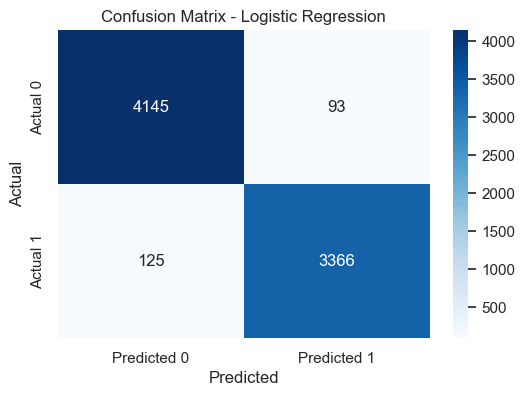

Confusion Matrix - Logistic Regression of title and text
Accuracy: 0.977746150860396

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4238
           1       0.99      0.97      0.98      3491

    accuracy                           0.98      7729
   macro avg       0.98      0.98      0.98      7729
weighted avg       0.98      0.98      0.98      7729



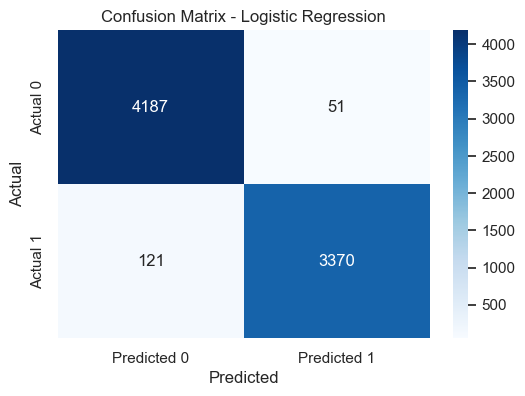

                        SO SÁNH LOGISTIC REGRESSION                        
Metric                         Title+Text       Text Only
---------------------------------------------------------------------------
Tin thật Precision                  0.972           0.971
Tin thật Recall                     0.988           0.978
Tin thật F1-score                   0.980           0.974
---------------------------------------------------------------------------
Tin giả Precision                   0.985           0.973
Tin giả Recall                      0.965           0.964
Tin giả F1-score                    0.975           0.969
---------------------------------------------------------------------------
Accuracy                            0.978           0.972


In [ ]:
# TRAIN CHO TEXT ONLY
print("Confusion Matrix - Logistic Regression of text only")
acc_lg_text, report_lg_text = train_logistic_regression(text_only_features)

# TRAIN CHO TITLE + TEXT
print("Confusion Matrix - Logistic Regression of title and text")
acc_lg_text_title, report_lg_text_title = train_logistic_regression(title_text_features)

compare_reports("LOGISTIC REGRESSION", acc_lg_text_title, report_lg_text_title, acc_lg_text, report_lg_text)   

### 10. Huấn luyện với mô hình Naive Bayes



In [ ]:
from sklearn.naive_bayes import MultinomialNB

def train_naive_bayes(feature_df):

    X = feature_df
    y = df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = MultinomialNB()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    
    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix - Naive Bayes')

    plt.show()

    return accuracy, report

### 11. Train & So sánh kết quả model Naive Bayes

Confusion Matrix - Naive Bayes of text only
Accuracy: 0.9466942683400181

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      4238
           1       0.96      0.92      0.94      3491

    accuracy                           0.95      7729
   macro avg       0.95      0.94      0.95      7729
weighted avg       0.95      0.95      0.95      7729



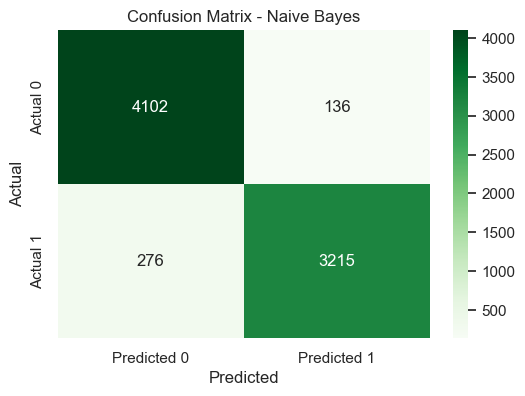

Confusion Matrix - Naive Bayes of title and text
Accuracy: 0.9424246344934661

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4238
           1       0.94      0.93      0.94      3491

    accuracy                           0.94      7729
   macro avg       0.94      0.94      0.94      7729
weighted avg       0.94      0.94      0.94      7729



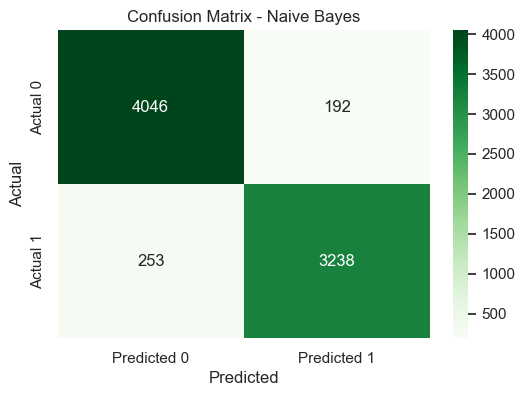

                            SO SÁNH NAIVE BAYES                            
Metric                         Title+Text       Text Only
---------------------------------------------------------------------------
Tin thật Precision                  0.941           0.937
Tin thật Recall                     0.955           0.968
Tin thật F1-score                   0.948           0.952
---------------------------------------------------------------------------
Tin giả Precision                   0.944           0.959
Tin giả Recall                      0.928           0.921
Tin giả F1-score                    0.936           0.940
---------------------------------------------------------------------------
Accuracy                            0.942           0.947


In [ ]:
print("Confusion Matrix - Naive Bayes of text only")
acc_nb_text, report_nb_text = train_naive_bayes(text_only_features)

print("Confusion Matrix - Naive Bayes of title and text")
acc_nb_text_title, report_nb_text_title = train_naive_bayes(title_text_features)

compare_reports("NAIVE BAYES", acc_nb_text_title, report_nb_text_title, acc_nb_text, report_nb_text)


### 12. Huấn luyện với mô hình SVM


In [ ]:
from sklearn.svm import LinearSVC

def train_svm(feature_df):

    X = feature_df
    y = df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LinearSVC(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    
    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix - SVM')

    plt.show()

    return accuracy, report

### 13. Train & So sánh kết quả model SVM

Confusion Matrix - SVM of text only
Accuracy: 0.970630094449476

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4238
           1       0.97      0.97      0.97      3491

    accuracy                           0.97      7729
   macro avg       0.97      0.97      0.97      7729
weighted avg       0.97      0.97      0.97      7729



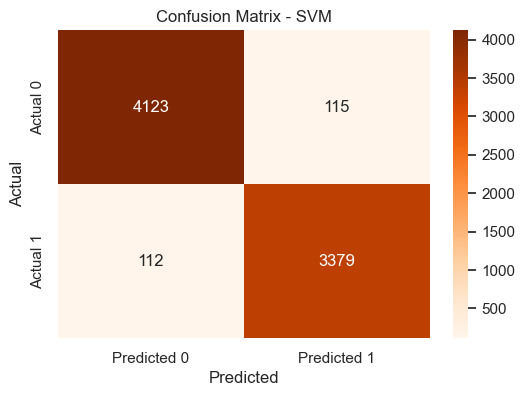

Confusion Matrix - SVM of title and text
Accuracy: 0.9755466425152025

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4238
           1       0.98      0.97      0.97      3491

    accuracy                           0.98      7729
   macro avg       0.98      0.98      0.98      7729
weighted avg       0.98      0.98      0.98      7729



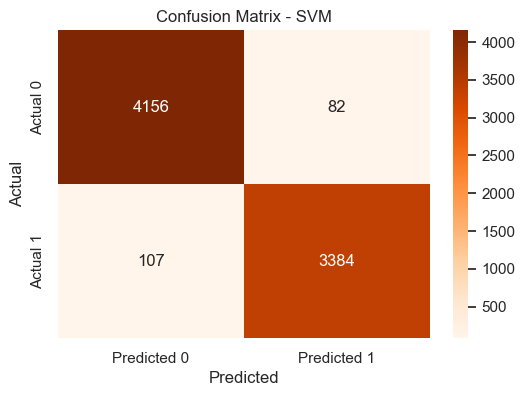

                                SO SÁNH SVM                                
Metric                         Title+Text       Text Only
---------------------------------------------------------------------------
Tin thật Precision                  0.975           0.974
Tin thật Recall                     0.981           0.973
Tin thật F1-score                   0.978           0.973
---------------------------------------------------------------------------
Tin giả Precision                   0.976           0.967
Tin giả Recall                      0.969           0.968
Tin giả F1-score                    0.973           0.968
---------------------------------------------------------------------------
Accuracy                            0.976           0.971


In [ ]:
print("Confusion Matrix - SVM of text only")
acc_svm_text, report_svm_text = train_svm(text_only_features)

print("Confusion Matrix - SVM of title and text")
acc_svm_text_title, report_svm_text_title = train_svm(title_text_features)

compare_reports( "SVM", acc_svm_text_title, report_svm_text_title, acc_svm_text, report_svm_text)


### 14. Bảng so sánh tổng kết quả thực nghiệm cho Title + text


In [ ]:
summary = pd.DataFrame({
    "Model": ["LR", "NB", "SVM"],
    "Title+Text": [acc_lg_text_title, acc_nb_text_title, acc_svm_text_title],
    "Text Only": [acc_lg_text, acc_nb_text, acc_svm_text]
})

print(summary)

  Model  Title+Text  Text Only
0    LR    0.977746   0.971795
1    NB    0.942425   0.946694
2   SVM    0.975547   0.970630


In [ ]:
# # --- THỬ NGHIỆM THỰC TẾ VỚI GIAO DIỆN ---
# import ipywidgets as widgets
# from IPython.display import display

# # Tạo giao diện nhập liệu
# text_area = widgets.Textarea(
#     value='',
#     placeholder='Dán nội dung bài báo tiếng Anh vào đây...',
#     description='Bài báo:',
#     disabled=False,
#     layout=widgets.Layout(width='100%', height='150px')
# )
# button = widgets.Button(description="Dự đoán", button_style='success')
# output = widgets.Output()

# display(text_area, button, output)

# def on_button_clicked(b):
#     with output:
#         output.clear_output()
#         news_text = text_area.value
#         if not news_text.strip():
#             print("Vui lòng nhập nội dung bài báo.")
#             return
        
#         # Tiền xử lý và vector hóa
#         news_cleaned = preprocess_text(news_text)
#         news_tfidf = vectorizer.transform([news_cleaned])
        
#         models = {
#             'Logistic Regression': LR,
#             'Decision Tree': DT,
#             'Random Forest': RF,
#             'Naive Bayes': NB,
#             'SVM': SVM
#         }
        
#         print(f"{'='*50}")
#         print("KẾT QUẢ DỰ ĐOÁN TỪ CÁC MÔ HÌNH:")
#         print(f"{'='*50}")
#         for name, model in models.items():
#             res = model.predict(news_tfidf)[0]
#             prob = model.predict_proba(news_tfidf)[0]
#             max_prob = max(prob) * 100
#             label_str = "Tin giả 🛑" if res == 1 else "Tin thật ✅"
#             print(f"- {name:<20}: {label_str:<12} (Xác suất: {max_prob:.2f}%)")
#         print(f"{'='*50}")

# button.on_click(on_button_clicked)


### 15. WordCloud

In [ ]:
fake_text = " ".join(df[df['label'] == 1]['text'])
true_text = " ".join(df[df['label'] == 0]['text'])

# WordCloud Fake News
wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Fake News")
plt.show()

# WordCloud True News
wc_true = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - True News")
plt.show()